In [8]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time

service = Service(ChromeDriverManager().install())
options = Options()
# options.add_argument("--headless")
# options.add_argument("--disable-gpu")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")
options.add_argument("--start-maximized")
options.add_argument("--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36")
options.add_argument("--lang=ko_KR")
options.add_argument("--no-sandbox")

target_url = "https://play.google.com/store/apps/details?id=com.coupang.mobile.play&hl=ko"
driver = webdriver.Chrome(service=service, options=options)
wait = WebDriverWait(driver, 10)

driver.get(target_url)
time.sleep(3)

# 리뷰 전체 보기 버튼
btn = driver.find_element(By.XPATH, "//*[@id='yDmH0d']/c-wiz[2]/div/div/div[1]/div/div[2]/div/div[1]/div[1]/c-wiz[5]/section/header/div/div[2]/button/i")
btn.click()
time.sleep(3)

# 정렬 옵션 클릭
btn2 = driver.find_element(By.XPATH, "//*[@id='sortBy_1']/div[2]/span[2]")
btn2.click()
time.sleep(2)

# 최신순 클릭
btn_new = driver.find_element(By.XPATH, "//*[@id='yDmH0d']/div[5]/div[2]/div/div/div/div/div[2]/div[2]/div/div/span[2]")
btn_new.click()
time.sleep(2)

reviews_data = []

for i in range(1, 3):   # 1점, 2점만
    # 별점 드롭다운 버튼 다시 열기
    rating_btn = wait.until(
        EC.element_to_be_clickable(
            (By.XPATH, "//*[@id='yDmH0d']/div[5]/div[2]/div/div/div/div/div[2]/div/div[1]/div/div/div/div[3]/div[2]/span[2]")
        )
    )
    rating_btn.click()
    time.sleep(1)

    # 별점 선택
    star_option = wait.until(
        EC.element_to_be_clickable((By.XPATH, f'//span[@aria-label="별 {i}개"]'))
    )
    star_option.click()
    time.sleep(2)

    review_cards = driver.find_elements(By.CSS_SELECTOR, "div.RHo1pe")

    for card in review_cards:
        try:
            name = card.find_element(By.XPATH, ".//header//div[contains(@class, 'X5PpBb')]").text.strip()
        except:
            name = ""

        try:
            date = card.find_element(By.CSS_SELECTOR, "span.bp9Aid").text.strip()
        except:
            date = ""

        try:
            comment = card.find_element(By.CSS_SELECTOR, "div.h3YV2d").text.strip()
        except:
            comment = ""

        reviews_data.append({
            "별점필터": f"{i}점",
            "작성자": name,
            "날짜": date,
            "댓글": comment
        })

for review in reviews_data:
    print(review)

driver.quit()

{'별점필터': '1점', '작성자': '박선미', '날짜': '2026년 4월 7일', '댓글': '아니;;;;돈내고 보는 OTT인데 솔직히 광고는 아니지않아요? 댜른거 다 참아도 광고는 씨 보라는거야 말라는거야 돈내고 소비자들 이렇게 막 대해도 되는겁니까? 참다참다 댓글쓰네요;:::'}
{'별점필터': '1점', '작성자': '띠의모', '날짜': '2026년 4월 6일', '댓글': '돈내고 보는데 나가 광고까지 쳐 봐야됨?'}
{'별점필터': '1점', '작성자': '스핔히', '날짜': '2026년 4월 6일', '댓글': '로그인 할려고 인증번호 입력해서 다음 버튼을 눌리는데 반응이 없음 뭐 어쩌란건가요? 어플 깔아서 로그인도 못하고 쓰지도 못하네요'}
{'별점필터': '1점', '작성자': 'Je N', '날짜': '2026년 4월 6일', '댓글': '광고좀적당히..무료를 하지말든가..몇개풀지도 않으면서 영상재생시간만큼 광고보는거같음...5분꼴로 한번씩나옴....'}
{'별점필터': '1점', '작성자': '노벨평화상수상자', '날짜': '2026년 4월 6일', '댓글': '와우회원도 광고 생기는 그저 갓팡플레이 해지할게요'}
{'별점필터': '1점', '작성자': 'sungwoon', '날짜': '2026년 4월 5일', '댓글': '와우회원도 광고가 나와서 불만이큰데 가끔 나오는것도 아니고 그냥 광고를 안보면 시청이 안됨 그래서 그냥 시청안하려고 함 그정성에 유튭이나 넷플 본다'}
{'별점필터': '1점', '작성자': '달달맛이', '날짜': '2026년 4월 5일', '댓글': '스카이라이 tv 요지꺼 보다가 tv 안나움 쿠팡 플레이앱 연결 안됨'}
{'별점필터': '1점', '작성자': '하밤', '날짜': '2026년 4월 5일', '댓글': '멤버십인데 광고가 왜 뜨나요?'}
{'별점필터': '1점', '작성자': 'jihun park', '날짜': '2026년 4월 5일', '댓글': '아니 무슨 유료회원한테 광고를 뜨게 만들어 

In [13]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from datetime import datetime
import pandas as pd
import time
import re

# -----------------------------
# 1. 브라우저 설정
# -----------------------------
service = Service(ChromeDriverManager().install())
options = Options()
# options.add_argument("--headless")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--window-size=1920,1080")
options.add_argument("--start-maximized")
options.add_argument("--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/144.0.0.0 Safari/537.36")
options.add_argument("--lang=ko_KR")
options.add_argument("--no-sandbox")

driver = webdriver.Chrome(service=service, options=options)
wait = WebDriverWait(driver, 10)

target_url = "https://play.google.com/store/apps/details?id=com.coupang.mobile.play&hl=ko"
driver.get(target_url)
time.sleep(3)

# -----------------------------
# 2. 날짜 변환 함수
# -----------------------------
def parse_review_date(date_text):
    """
    예: '2026년 4월 7일' -> datetime 객체
    """
    match = re.search(r"(\d{4})년\s*(\d{1,2})월\s*(\d{1,2})일", date_text)
    if match:
        year, month, day = map(int, match.groups())
        return datetime(year, month, day)
    return None

# 수집 기준 날짜
start_date = datetime(2025, 12, 1)
end_date = datetime(2026, 12, 31)

# -----------------------------
# 3. 리뷰 전체 보기 열기
# -----------------------------
btn = driver.find_element(By.XPATH, "//*[@id='yDmH0d']/c-wiz[2]/div/div/div[1]/div/div[2]/div/div[1]/div[1]/c-wiz[5]/section/header/div/div[2]/button/i")
btn.click()
time.sleep(3)

# -----------------------------
# 4. 최신순 정렬
# -----------------------------
btn2 = driver.find_element(By.XPATH, "//*[@id='sortBy_1']/div[2]/span[2]")
btn2.click()
time.sleep(1)

btn_new = driver.find_element(
    By.XPATH,
    "//*[@id='yDmH0d']/div[5]/div[2]/div/div/div/div/div[2]/div[2]/div/div/span[2]"
)
btn_new.click()
time.sleep(2)

# -----------------------------
# 5. 데이터 저장 변수
# -----------------------------
all_reviews = []
rating_count_dict = {}

# -----------------------------
# 6. 별점 1점, 2점 반복
# -----------------------------
for i in range(1, 3):
    print(f"\n===== {i}점 리뷰 수집 시작 =====")

    # 별점 드롭다운 열기
    rating_btn = wait.until(
        EC.element_to_be_clickable(
            (By.XPATH, "//*[@id='yDmH0d']/div[5]/div[2]/div/div/div/div/div[2]/div/div[1]/div/div/div/div[3]/div[2]/span[2]")
        )
    )
    rating_btn.click()
    time.sleep(1)

    # 별점 선택
    star_option = wait.until(
        EC.element_to_be_clickable((By.XPATH, f'//span[@aria-label="별 {i}개"]'))
    )
    star_option.click()
    time.sleep(2)

    # 리뷰 팝업 내부 스크롤 영역
    scroll_box = wait.until(
        EC.presence_of_element_located(
            (By.XPATH, "//div[@role='dialog']//div[contains(@class, 'fysCi')]")
        )
    )

    last_height = driver.execute_script("return arguments[0].scrollHeight", scroll_box)

    # -----------------------------
    # 7. 날짜 기준까지 스크롤
    # -----------------------------
    while True:
        review_cards = driver.find_elements(By.CSS_SELECTOR, "div.RHo1pe")

        # 마지막 3개 카드 기준으로 날짜 체크
        stop_scroll = False
        last_cards = review_cards[-3:] if len(review_cards) >= 3 else review_cards

        for card in last_cards:
            try:
                date_text = card.find_element(By.CSS_SELECTOR, "span.bp9Aid").text.strip()
                review_date = parse_review_date(date_text)

                # 2025년 12월보다 이전 날짜가 보이면 중단
                if review_date and review_date < start_date:
                    print(f"{i}점: 스크롤 중단 기준 도달 -> {date_text}")
                    stop_scroll = True
                    break
            except:
                pass

        if stop_scroll:
            break

        # 스크롤 내리기
        driver.execute_script("arguments[0].scrollTop = arguments[0].scrollHeight", scroll_box)
        time.sleep(2)

        new_height = driver.execute_script("return arguments[0].scrollHeight", scroll_box)

        # 더 이상 로딩 안 되면 종료
        if new_height == last_height:
            print(f"{i}점: 더 이상 로딩할 리뷰 없음")
            break

        last_height = new_height

    # -----------------------------
    # 8. 현재 로딩된 리뷰 카드 수집
    # -----------------------------
    review_cards = driver.find_elements(By.CSS_SELECTOR, "div.RHo1pe")
    filtered_count = 0

    for card in review_cards:
        try:
            name = card.find_element(
                By.XPATH,
                './/header//div[contains(@class, "X5PpBb")]'
            ).text.strip()
        except:
            name = ""

        try:
            date = card.find_element(By.CSS_SELECTOR, "span.bp9Aid").text.strip()
        except:
            date = ""

        try:
            comment = card.find_element(By.CSS_SELECTOR, "div.h3YV2d").text.strip()
        except:
            comment = ""

        review_date = parse_review_date(date)

        if review_date and start_date <= review_date <= end_date:
            all_reviews.append({
                "별점필터": f"{i}점",
                "작성자": name,
                "날짜": date,
                "댓글": comment
            })
            filtered_count += 1

    rating_count_dict[f"{i}점"] = filtered_count
    print(f"{i}점 필터 수집 개수: {filtered_count}")

# -----------------------------
# 9. 중복 제거
# -----------------------------
seen = set()
clean_reviews = []

for row in all_reviews:
    key = (row["별점필터"], row["작성자"], row["날짜"], row["댓글"])
    if key not in seen:
        seen.add(key)
        clean_reviews.append(row)

all_reviews = clean_reviews

# -----------------------------
# 10. 중복 제거 후 별점별 재집계
# -----------------------------
rating_count_dict = {}
for row in all_reviews:
    rating = row["별점필터"]
    rating_count_dict[rating] = rating_count_dict.get(rating, 0) + 1

# -----------------------------
# 11. 결과 출력
# -----------------------------
print("\n===== 최종 별점별 댓글 개수 =====")
for k, v in rating_count_dict.items():
    print(f"{k}: {v}개")

print(f"\n전체 수집 개수: {len(all_reviews)}개")

# -----------------------------
# 12. 데이터프레임 생성
# -----------------------------
df_reviews = pd.DataFrame(all_reviews)
print(df_reviews.head())

# 필요하면 CSV 저장
# df_reviews.to_csv("coupangplay_reviews_202512_2026.csv", index=False, encoding="utf-8-sig")

driver.quit()


===== 1점 리뷰 수집 시작 =====
1점: 스크롤 중단 기준 도달 -> 2025년 11월 25일
1점 필터 수집 개수: 287

===== 2점 리뷰 수집 시작 =====
2점: 스크롤 중단 기준 도달 -> 2025년 11월 29일
2점 필터 수집 개수: 38

===== 최종 별점별 댓글 개수 =====
1점: 287개
2점: 38개

전체 수집 개수: 325개
  별점필터       작성자           날짜  \
0   1점       박선미  2026년 4월 7일   
1   1점       띠의모  2026년 4월 6일   
2   1점       스핔히  2026년 4월 6일   
3   1점      Je N  2026년 4월 6일   
4   1점  노벨평화상수상자  2026년 4월 6일   

                                                  댓글  
0  아니;;;;돈내고 보는 OTT인데 솔직히 광고는 아니지않아요? 댜른거 다 참아도 광...  
1                             돈내고 보는데 나가 광고까지 쳐 봐야됨?  
2  로그인 할려고 인증번호 입력해서 다음 버튼을 눌리는데 반응이 없음 뭐 어쩌란건가요?...  
3  광고좀적당히..무료를 하지말든가..몇개풀지도 않으면서 영상재생시간만큼 광고보는거같음...  
4                        와우회원도 광고 생기는 그저 갓팡플레이 해지할게요  


In [14]:
df_reviews.to_csv("coupangplay_reviews_202512_2026.csv", index=False, encoding="utf-8-sig")

In [15]:
!pip install wordcloud konlpy

   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   - -------------------------------------- 0.5/19.4 MB 3.8 MB/s eta 0:00:06
   -- ------------------------------------- 1.0/19.4 MB 2.5 MB/s eta 0:00:08
   --- ------------------------------------ 1.8/19.4 MB 2.9 MB/s eta 0:00:07
   ---- ----------------------------------- 2.4/19.4 MB 2.9 MB/s eta 0:00:06
   ------ --------------------------------- 3.1/19.4 MB 3.1 MB/s eta 0:00:06
   ------- -------------------------------- 3.7/19.4 MB 3.0 MB/s eta 0:00:06
   --------- ------------------------------ 4.5/19.4 MB 3.1 MB/s eta 0:00:05
   ---------- ----------------------------- 5.2/19.4 MB 3.2 MB/s eta 0:00:05
   ------------ --------------------------- 6.0/19.4 MB 3.3 MB/s eta 0:00:05
   -------------- ------------------------- 6.8/19.4 MB 3.2 MB/s eta 0:00:04
   --------------- ------------------------ 7.6/19.4 MB 3.3 MB/s eta 0:00:04
   ---------------- ----------------------- 8.1/19.4 MB 3.3 MB/s eta 0:00:04
   ---

In [6]:
import pandas as pd

df = pd.read_csv("coupangplay_reviews_202512_2026.csv", encoding="utf-8-sig")

In [7]:
df

,별점필터,작성자,날짜,댓글
0,1점,박선미,2026년 4월 7일,아니;;;;돈내고 보는 OTT인데 솔직히 광고는 아니지않아요? 댜른거 다 참아도 광...
1,1점,띠의모,2026년 4월 6일,돈내고 보는데 나가 광고까지 쳐 봐야됨?
2,1점,스핔히,2026년 4월 6일,로그인 할려고 인증번호 입력해서 다음 버튼을 눌리는데 반응이 없음 뭐 어쩌란건가요?...
3,1점,Je N,2026년 4월 6일,광고좀적당히..무료를 하지말든가..몇개풀지도 않으면서 영상재생시간만큼 광고보는거같음...
4,1점,노벨평화상수상자,2026년 4월 6일,와우회원도 광고 생기는 그저 갓팡플레이 해지할게요
...,...,...,...,...
320,2점,우선10억,2025년 12월 7일,스포츠채널 다시보기 하면 4k화질 제공하는 하이라이트 영상도 갑자기 480p화질로 ...
321,2점,김소현,2025년 12월 7일,콘텐츠 찜하기가 계속 안돼요..... 빨리 오류 좀 고쳐주세요!!!
322,2점,지태빈,2025년 12월 6일,끼워팔기에 돈을 그렇게 빨아먹으면서 동시시청도 못하게 막는 건 무슨 개짓거리냐? 양...
323,2점,안혜민,2025년 12월 1일,솔직히 볼게없음 업데이트된것도 늘 너무없고 그냥ㅇ볼게없음


       단어  빈도수
0      광고   30
1      와우   27
2     광고를   21
3      다시   17
4     스포츠   16
5     돈내고   15
6     보는데   15
7   쿠팡플레이   15
8      자꾸   15
9      없음   14
10     아니   13
11    광고가   13
12     계속   13
13   업데이트   11
14     안됨   10
15    광고는    9
16     무슨    9
17    갑자기    9
18     영화    9
19   개인정보    9


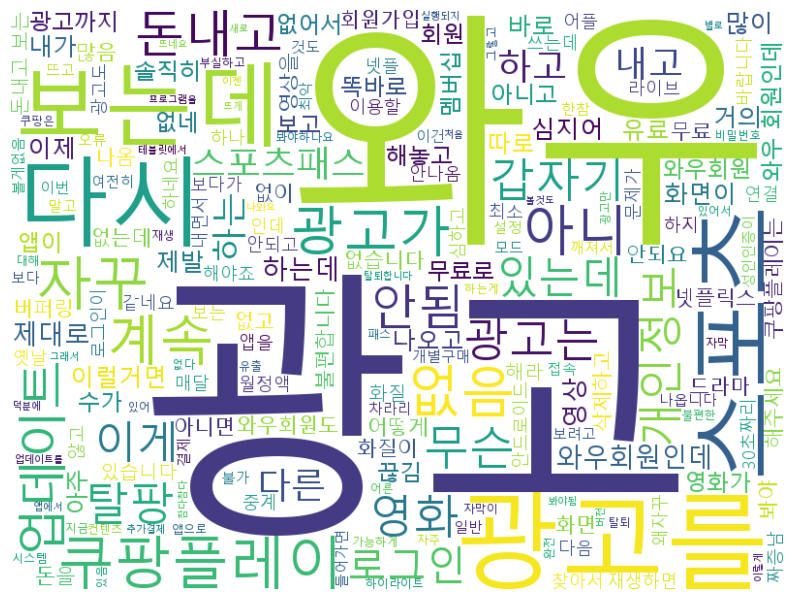

In [9]:
from wordcloud import WordCloud
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import re

text = " ".join(df["댓글"].dropna().astype(str))

# 특수문자 제거
text = re.sub(r"[^가-힣0-9\s]", " ", text)

# 단어 분리
words = text.split()

# 2글자 이상만
words = [word for word in words if len(word) > 1]

# 불용어 제거
stopwords = [
    "쿠팡", "플레이", "진짜", "그냥", "정말", "너무", "이거", "저거",
    "합니다", "있어요", "같아요", "그리고", "근데", "해서", "하면",
    "있는", "없는", "으로", "에서", "합니다", "사용", "앱", "리뷰"
]
words = [word for word in words if word not in stopwords]

# 빈도수 확인
word_count = Counter(words)
top20 = word_count.most_common(20)

df_word = pd.DataFrame(top20, columns=["단어", "빈도수"])
print(df_word)

# 워드클라우드
final_text = " ".join(words)

wc = WordCloud(
    font_path="C:/Windows/Fonts/malgun.ttf",
    background_color="white",
    width=800,
    height=600
).generate(final_text)

plt.figure(figsize=(10, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")

plt.savefig("wordcloud.png")
plt.show()


In [10]:
uiux_dict = {
    "광고 불만": [
        "광고", "광고 많", "광고 너무", "중간광고", "강제광고",
        "광고 때문에", "광고만", "광고 짜증",
        "무료라면서", "유료인데 광고", "돈내고 광고"
    ],
    
    "재생/성능": [
        "버벅", "멈춤", "느림", "로딩", "렉", "끊김", "튕김",
        "오류", "재생 안", "안됨", "먹통", "실행 안",
        "에러", "에러코드", "연결 안됨", "화면 안나옴"
    ],
    
    "탐색/UI": [
        "불편", "복잡", "불친절", "찾기", "검색", "메뉴",
        "화면", "헷갈림", "직관", "인터페이스",
        "보기 힘들", "UI", "UX", "자막", "화질", "음질", "소리",
        "이어보기", "다음화", "전체화면",
        "자막 오류", "화질 문제"
    ],
    
    "콘텐츠 이용": [
        "볼게없", "콘텐츠", "컨텐츠", "영화 없음", "볼게 없음",
        "작품", "라인업", "무료 콘텐츠", "유료 콘텐츠",
        "구매", "패스", "볼만한"
    ],
    
    "계정/결제": [
        "로그인", "결제", "인증", "업데이트", "회원", "계정", "접속",
        "로그아웃", "비밀번호", "가입"
    ]
}

In [11]:
def normalize_text(text):
    text = str(text)
    text = text.replace("컨텐츠", "콘텐츠")
    text = text.replace("볼게없다", "볼게없")
    return text

In [12]:
def find_category(comment):
    comment = normalize_text(comment)

    # 광고 최우선
    for kw in ad_keywords:
        if kw in comment:
            return ["광고 불만"]

    matched = []

    for category, keywords in uiux_dict.items():
        for kw in keywords:
            if kw in comment:
                matched.append(category)
                break

    if not matched:
        matched.append("기타")

    return matched

In [13]:
df_reviews["카테고리"] = df_reviews["댓글"].apply(find_uiux_category)

NameError: name 'df_reviews' is not defined

In [35]:
df_reviews[["댓글", "카테고리"]].head(10)

,댓글,카테고리
0,아니;;;;돈내고 보는 OTT인데 솔직히 광고는 아니지않아요? 댜른거 다 참아도 광...,[광고 불만]
1,돈내고 보는데 나가 광고까지 쳐 봐야됨?,[광고 불만]
2,로그인 할려고 인증번호 입력해서 다음 버튼을 눌리는데 반응이 없음 뭐 어쩌란건가요?...,[계정/결제]
3,광고좀적당히..무료를 하지말든가..몇개풀지도 않으면서 영상재생시간만큼 광고보는거같음...,[광고 불만]
4,와우회원도 광고 생기는 그저 갓팡플레이 해지할게요,[광고 불만]
5,와우회원도 광고가 나와서 불만이큰데 가끔 나오는것도 아니고 그냥 광고를 안보면 시청...,[광고 불만]
6,스카이라이 tv 요지꺼 보다가 tv 안나움 쿠팡 플레이앱 연결 안됨,[재생/성능]
7,멤버십인데 광고가 왜 뜨나요?,[광고 불만]
8,아니 무슨 유료회원한테 광고를 뜨게 만들어 놨냐? 제정신임??,[광고 불만]
9,와우 회원도 광고 나와요 ㅋㅋ,[광고 불만]


In [36]:
from collections import Counter
import pandas as pd

category_counter = Counter()

for cats in df_reviews["카테고리"]:
    for c in cats:
        category_counter[c] += 1

df_category = pd.DataFrame(
    category_counter.items(),
    columns=["카테고리", "빈도수"]
).sort_values("빈도수", ascending=False)

print(df_category)

     카테고리  빈도수
4   기타 불만  120
0   광고 불만   87
1   계정/결제   61
2   재생/성능   40
3   탐색/UI   31
5  콘텐츠 이용   24


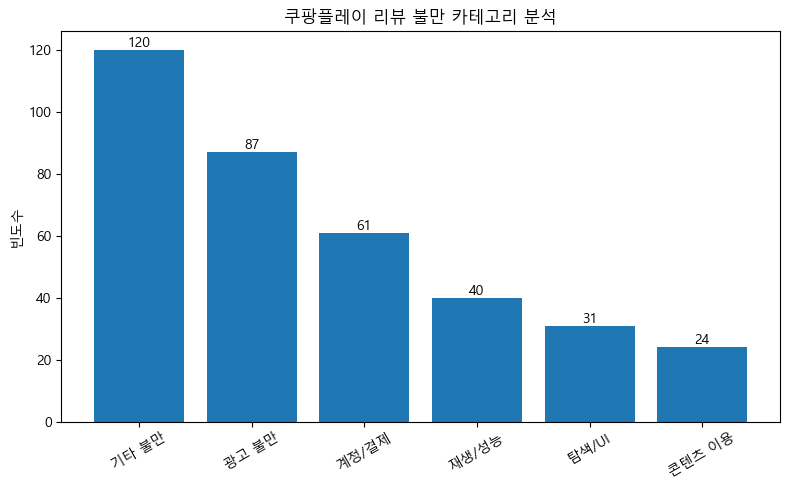

In [43]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))
bars = plt.bar(df_category["카테고리"], df_category["빈도수"])

plt.xticks(rotation=30)
plt.title("쿠팡플레이 리뷰 불만 카테고리 분석")
plt.ylabel("빈도수")

# 🔥 여기 핵심
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.savefig("category_bar.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
total = len(df_reviews)

ad_count = sum(["광고 불만" in c for c in df_reviews["카테고리"]])

print("전체 리뷰:", total)
print("광고 불만:", ad_count)
print("광고 비율:", round(ad_count / total * 100, 2), "%")

전체 리뷰: 325
광고 불만: 87
광고 비율: 26.77 %


In [39]:
for category in df_category["카테고리"]:
    print(f"\n===== {category} =====")
    sample = df_reviews[df_reviews["카테고리"].apply(lambda x: category in x)]["댓글"].head(5)
    for i, comment in enumerate(sample, 1):
        print(f"{i}. {comment}")


===== 기타 불만 =====
1. snl 원툴
2. 에러코드 2001번 좀 고쳐주셈. 잘되는데 계속 튕기네요
3. 볼게없다 옛날 유플러스 전략을 그대로 이어가는 중, 볼만한건 다 구매. 패스에 넣어놓고 오래된 컨텐츠만 무료로 생색내기 곧 망할듯
4. 무료라면서 개 뻥 1가도 아까움
5. 요즘도 쿠팡 쓰는사람은...

===== 광고 불만 =====
1. 아니;;;;돈내고 보는 OTT인데 솔직히 광고는 아니지않아요? 댜른거 다 참아도 광고는 씨 보라는거야 말라는거야 돈내고 소비자들 이렇게 막 대해도 되는겁니까? 참다참다 댓글쓰네요;:::
2. 돈내고 보는데 나가 광고까지 쳐 봐야됨?
3. 광고좀적당히..무료를 하지말든가..몇개풀지도 않으면서 영상재생시간만큼 광고보는거같음...5분꼴로 한번씩나옴....
4. 와우회원도 광고 생기는 그저 갓팡플레이 해지할게요
5. 와우회원도 광고가 나와서 불만이큰데 가끔 나오는것도 아니고 그냥 광고를 안보면 시청이 안됨 그래서 그냥 시청안하려고 함 그정성에 유튭이나 넷플 본다

===== 계정/결제 =====
1. 로그인 할려고 인증번호 입력해서 다음 버튼을 눌리는데 반응이 없음 뭐 어쩌란건가요? 어플 깔아서 로그인도 못하고 쓰지도 못하네요
2. 필수 업데이트를 지나치게 자주합니다. 업데이트하지 않으면 아예 프로그램 시작도 못하고있는건 버전 배포 시스템에 문제가 있다는겁니다.
3. 잘사용하던 안드로이드 6.0.1 버전 테블릿에서 쿠팡플레이 더이상 실행되지 않습니다 또한 구글스토어 에서 검색도 되지않고 쿠팡앱도 태블릿에서 사용할수 없습니다 유튜브처럼 크롬브라우저에서 볼수도 없습니다 태블릿 안드로이드 6.0.1 에서 쿠팡플레이가 실행되지 않는다면 PC처럼 브라우저를 통해서 볼수있도록은 해야죠.. 개발자분들 확인좀 하시면서 개발이던 업데이트던 해주시고 조속히 해결책을 찾아서 공지해 주시기를 바랍니다
4. 로그인이 안되요.껐다켜도안되고 지웠다설치해도안되요
5. 로그인이 안됩니다. 쿠팡로그인후에 쿠팡플레이로 들어가도 다시 로그인하라고 

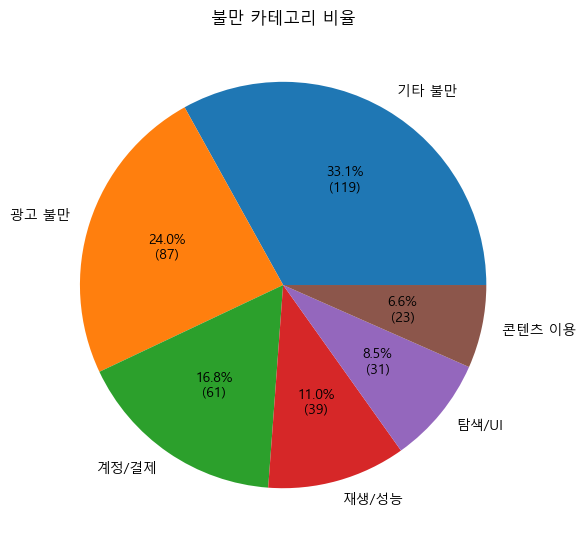

In [44]:
plt.figure(figsize=(6, 6))

plt.pie(
    df_category["빈도수"],
    labels=df_category["카테고리"],
    autopct=lambda p: f'{p:.1f}%\n({int(p * sum(df_category["빈도수"]) / 100)})'
)

plt.title("불만 카테고리 비율")
plt.tight_layout()

plt.savefig("category_pie.png", dpi=300, bbox_inches="tight")
plt.show()